# Задача 8. Симуляция марковской цепи

**Цель:** сгенерировать синтетическую ДНК-последовательность по марковской модели.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [4]:
nucleotides = ['A', 'C', 'G', 'T']
P = np.array([
    [0.371528, 0.122790, 0.196654, 0.309028],
    [0.313514, 0.173574, 0.156757, 0.356156],  
    [0.355844, 0.199481, 0.187532, 0.257143],  
    [0.242209, 0.185745, 0.209812, 0.362234], 
])

In [6]:
def generate_sequence(P, length, start_state): # генерирует последовательность длиной length, начиная с нуклеотида start_state
    start_state = nucleotides.index(start_state)
    sequence = [start_state]
    current = start_state

    for _ in range(length - 1):
        row = P[current] / P[current].sum() 
        next_state = np.random.choice(len(nucleotides), p=row)
        sequence.append(next_state)
        current = next_state

    # Возвращаем строку букв
    return ''.join(nucleotides[i] for i in sequence)

In [7]:
def compute_dinucleotide_frequencies(sequence):
    counts = np.zeros((4, 4))

    for k in range(len(sequence) - 1):
        i = nucleotides.index(sequence[k])      # текущая буква → индекс
        j = nucleotides.index(sequence[k + 1])  # следующая буква → индекс
        counts[i][j] += 1

    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums

In [9]:
#генерируем 10 последовательностей
np.random.seed(42)

n_sequences = 10
seq_length = 1000

all_freq_matrices = []

for i in range(n_sequences):
    seq = generate_sequence(P, seq_length, 'A')  # теперь передаём букву
    freq = compute_dinucleotide_frequencies(seq)
    all_freq_matrices.append(freq)

In [10]:
mean_freq = np.mean(all_freq_matrices, axis=0)
diff = np.abs(P - mean_freq)

print(f"Среднее отклонение:    {diff.mean():.4f}")
print(f"Максимальное отклонение: {diff.max():.4f}")

Среднее отклонение:    0.0063
Максимальное отклонение: 0.0167


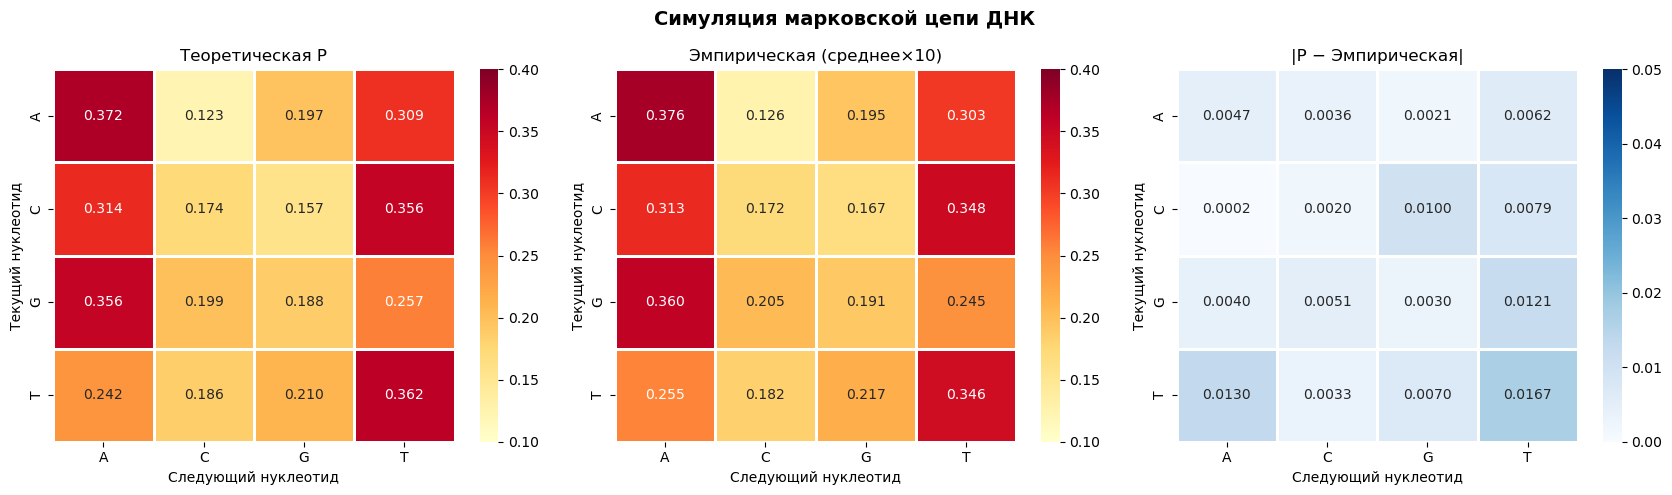

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Симуляция марковской цепи ДНК', fontsize=14, fontweight='bold')

common = dict(
    annot=True, fmt=".3f",
    xticklabels=nucleotides, yticklabels=nucleotides,
    linewidths=0.8, linecolor='white',
    vmin=0.10, vmax=0.40, cmap="YlOrRd"
)

sns.heatmap(P,         ax=axes[0], **common)
sns.heatmap(mean_freq, ax=axes[1], **common)
sns.heatmap(diff,      ax=axes[2], cmap="Blues", vmin=0, vmax=0.05,
            annot=True, fmt=".4f",
            xticklabels=nucleotides, yticklabels=nucleotides,
            linewidths=0.8, linecolor='white')

axes[0].set_title('Теоретическая P')
axes[1].set_title('Эмпирическая (среднее×10)')
axes[2].set_title('|P − Эмпирическая|')

for ax in axes:
    ax.set_xlabel('Следующий нуклеотид')
    ax.set_ylabel('Текущий нуклеотид')

plt.tight_layout()
plt.savefig('markov_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

Видим, что карты 1 и 2 визуально почти идентичны - одинаковые цвета на одних и тех же местах показывают, что частоты очень близки по значениям. Карта 3 - карта разности значений между теоретической P и полученной показывает очень маленькие значения (все в светлой зоне). Соответсвенно, можно сделать вывод, что марковская цепь в данной реализации правильно воспроизводит заданную матрицу P.